In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

def huber_loss(w, eta):
    return np.where(np.abs(w) <= eta, 0.5 * w**2, eta * (np.abs(w) - 0.5 * eta))

def huber_grad(w, eta):
    return np.where(np.abs(w) <= eta, w, eta * np.sign(w))

def huberized_objective(x, A, y, lmbda, eta):
    w = y - A @ x
    return np.sum(huber_loss(w, eta)) + 0.5 * lmbda * np.linalg.norm(x)**2

def huberized_gradient(x, A, y, lmbda, eta):
    w = y - A @ x
    grad_loss = -A.T @ huber_grad(w, eta)
    grad_reg = lmbda * x
    return grad_loss + grad_reg

def gradient_descent(A, y, lmbda, eta, beta, num_iters=50):
    n = A.shape[1]
    x = np.zeros(n)
    f_values = []
    alpha = 1 / beta  #Step size

    for k in range(num_iters):
        grad = huberized_gradient(x, A, y, lmbda, eta)
        x = x - alpha * grad
        f_values.append(huberized_objective(x, A, y, lmbda, eta))
    return f_values

def accelerated_gradient_descent(A, y, lmbda, eta, beta, num_iters=50):
    n = A.shape[1]
    x = np.zeros(n)
    z = np.zeros(n)
    f_values = []
    alpha = 1 / beta  #Step size
    gamma = 0
    for k in range(num_iters):
        prev_x = x.copy()
        grad = huberized_gradient(z, A, y, lmbda, eta)
        x = z - alpha * grad
        if k == 0:
            gamma = 0
        else:
            gamma = (np.sqrt(beta) - np.sqrt(lmbda)) / (np.sqrt(beta) + np.sqrt(lmbda))
        z = x + gamma * (x - prev_x)
        f_values.append(huberized_objective(x, A, y, lmbda, eta))
    return f_values

n = 100
m = 80
lmbda = 1

beta = 4*(m+n) + lmbda

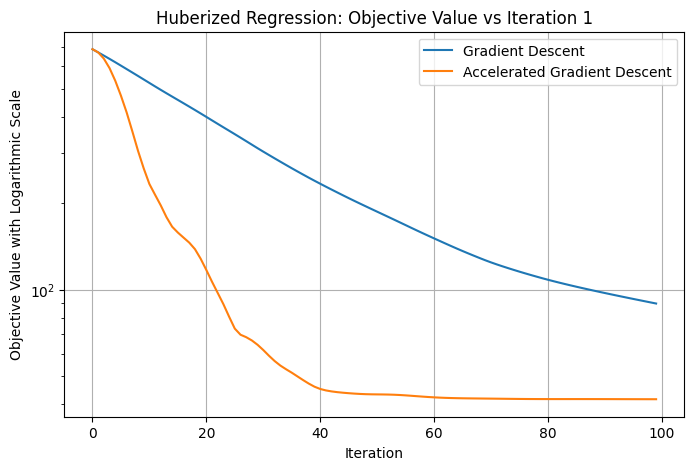

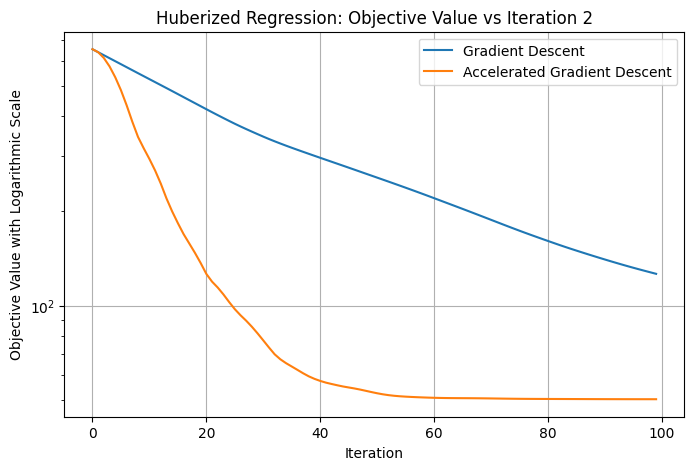

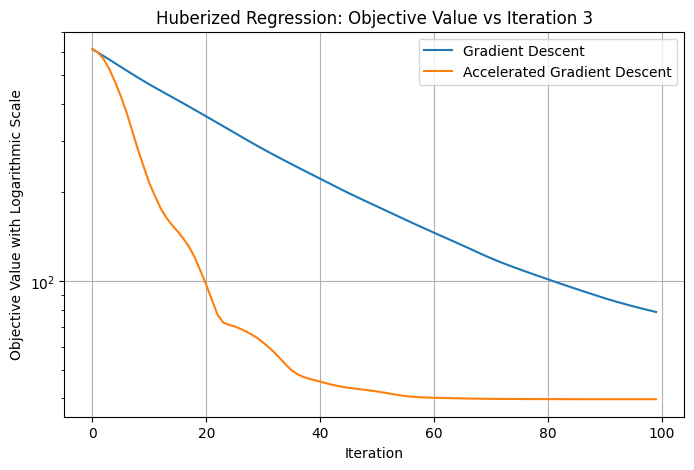

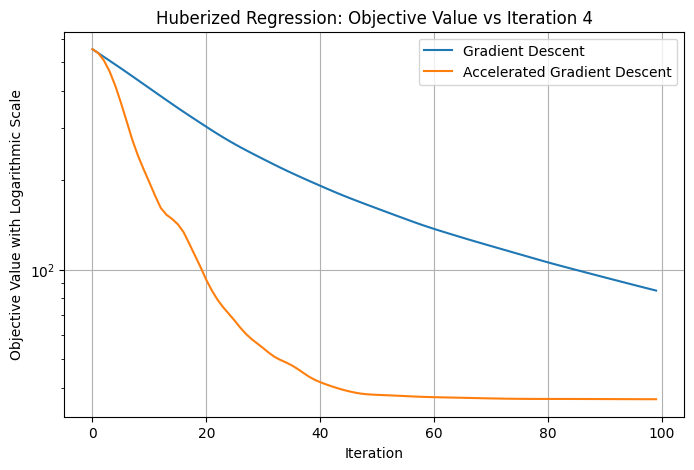

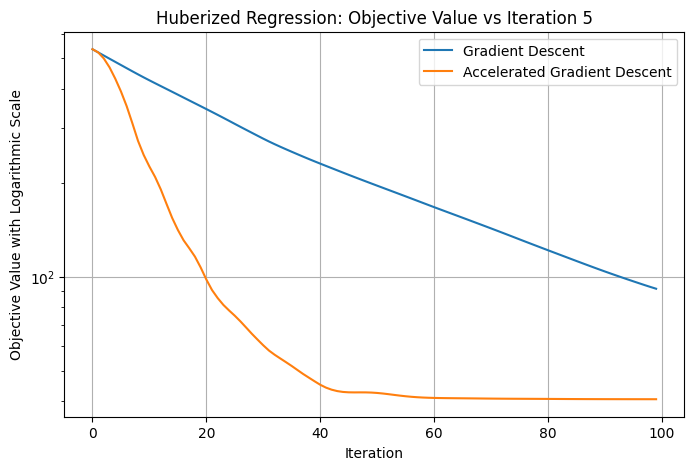

In [14]:
eta = 1.0

for i in range(5):
    x_opt = np.random.randn(n)
    A = np.random.randn(m, n)
    myVariance = 0.25
    mySTD = math.sqrt(myVariance)
    epsilon = np.random.normal(0, mySTD, m)
    
    outlier_indices = np.random.choice(m, size=5, replace=False)
    mu = 0
    outliers_drawn = 25
    kempSTD = math.sqrt(outliers_drawn)
    epsilon[outlier_indices] = np.random.normal(mu, kempSTD, 5)
    y = A @ x_opt + epsilon
    
    gd_values = gradient_descent(A, y, lmbda, eta, beta, num_iters=100)
    agd_values = accelerated_gradient_descent(A, y, lmbda, eta, beta, num_iters=100)
    
    plt.figure(figsize=(8, 5))
    plt.semilogy(gd_values, label = "Gradient Descent")
    plt.semilogy(agd_values, label = "Accelerated Gradient Descent")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Value with Logarithmic Scale")
    plt.title("Huberized Regression: Objective Value vs Iteration "+str(i+1))
    plt.legend()
    plt.grid(True)
    plt.show()

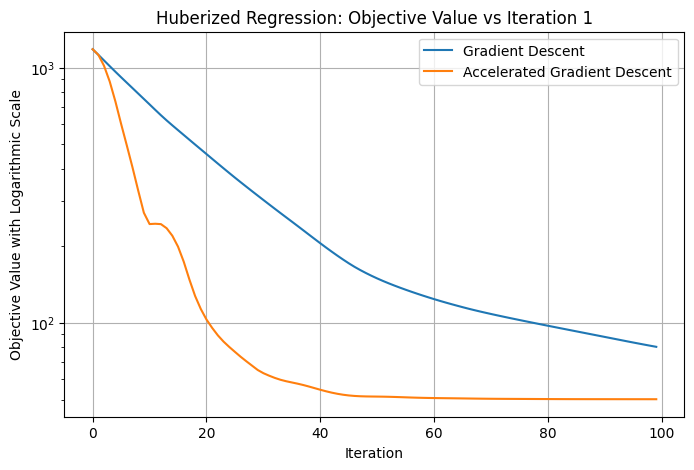

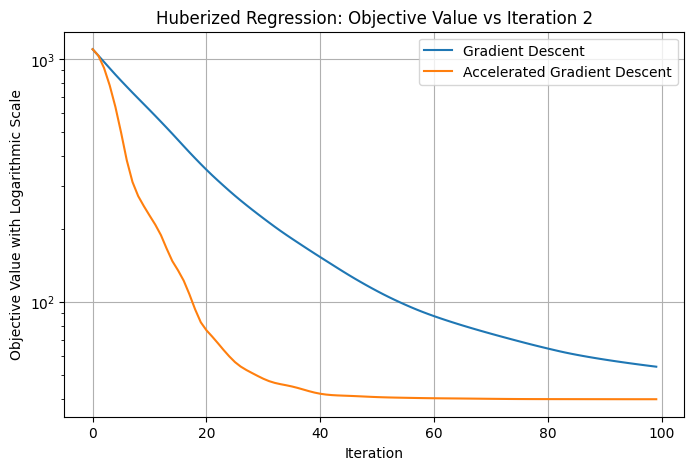

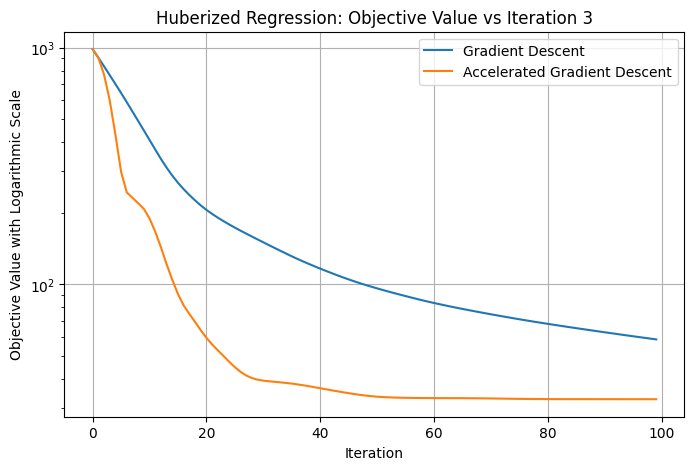

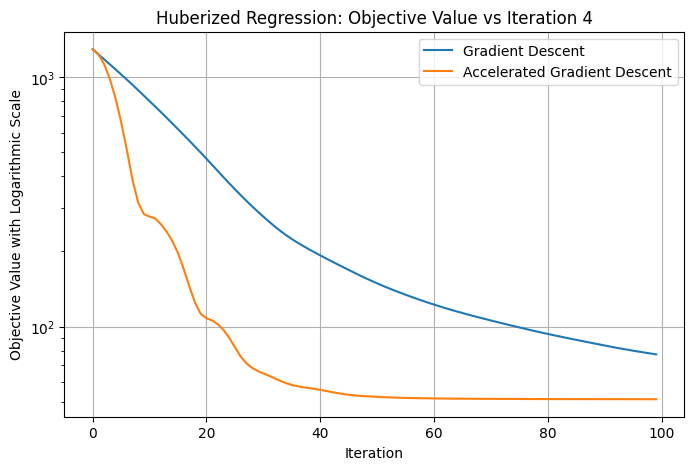

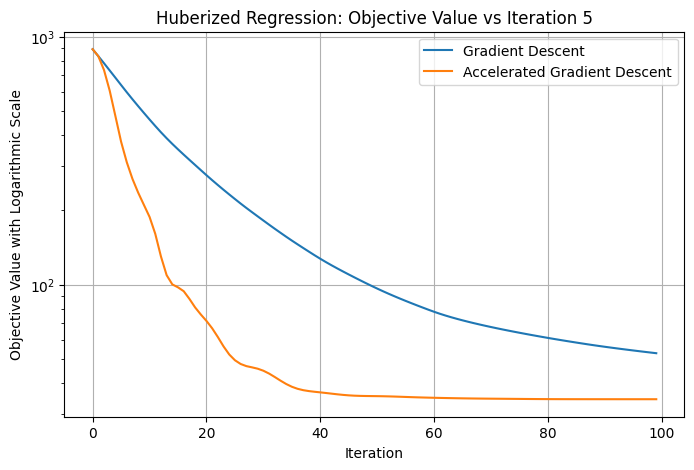

In [15]:
eta = 2.0

for i in range(5):
    x_opt = np.random.randn(n)
    A = np.random.randn(m, n)
    myVariance = 0.25
    mySTD = math.sqrt(myVariance)
    epsilon = np.random.normal(0, mySTD, m)
    
    outlier_indices = np.random.choice(m, size=5, replace=False)
    mu = 0
    outliers_drawn = 25
    kempSTD = math.sqrt(outliers_drawn)
    epsilon[outlier_indices] = np.random.normal(mu, kempSTD, 5)
    y = A @ x_opt + epsilon
    
    gd_values = gradient_descent(A, y, lmbda, eta, beta, num_iters=100)
    agd_values = accelerated_gradient_descent(A, y, lmbda, eta, beta, num_iters=100)
    
    plt.figure(figsize=(8, 5))
    plt.semilogy(gd_values, label = "Gradient Descent")
    plt.semilogy(agd_values, label = "Accelerated Gradient Descent")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Value with Logarithmic Scale")
    plt.title("Huberized Regression: Objective Value vs Iteration "+str(i+1))
    plt.legend()
    plt.grid(True)
    plt.show()

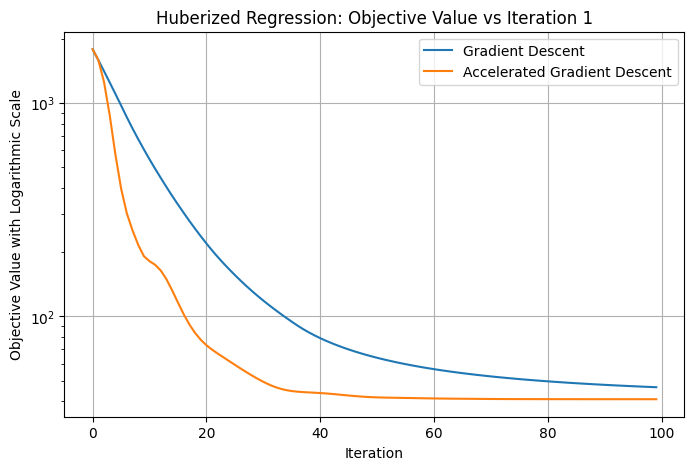

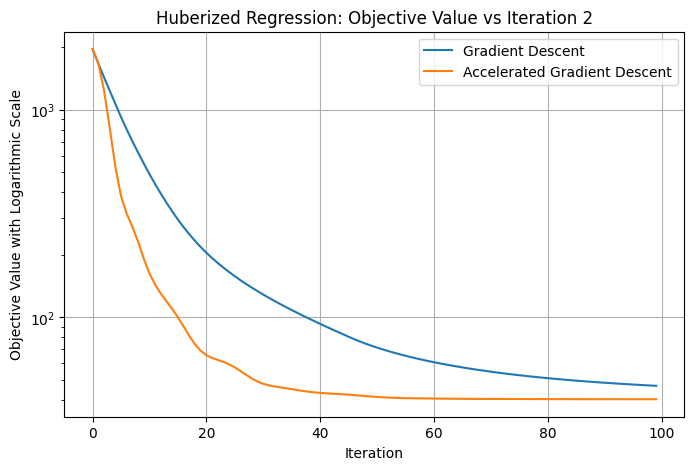

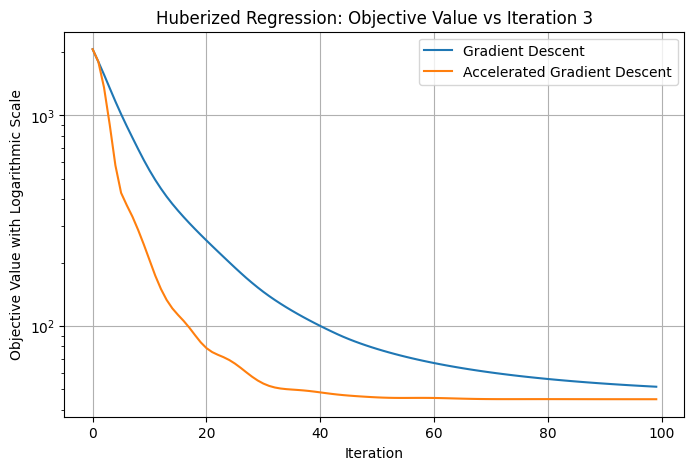

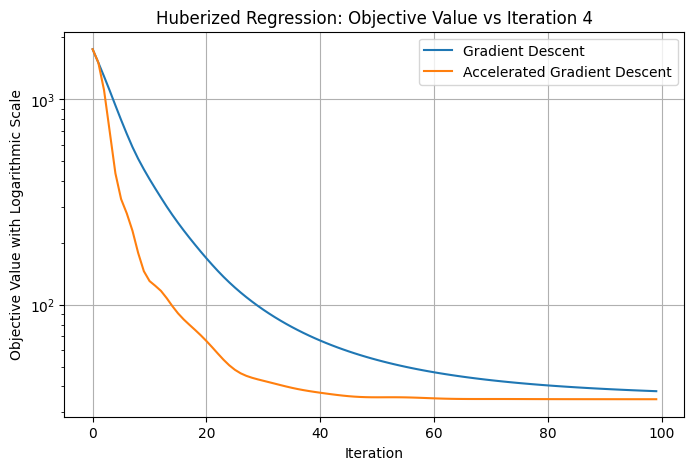

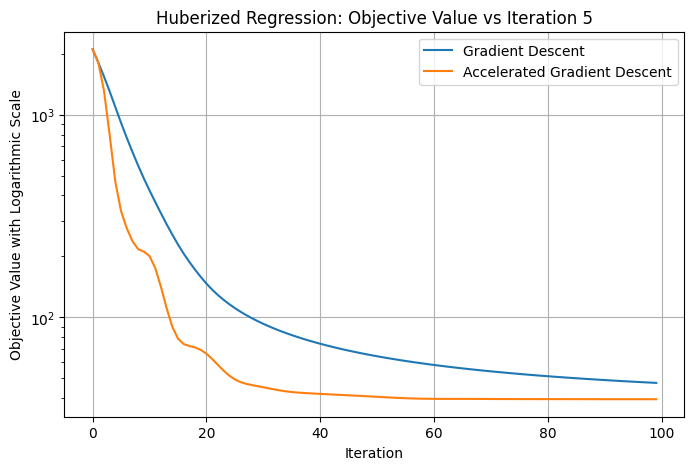

In [16]:
eta = 5.0

for i in range(5):
    x_opt = np.random.randn(n)
    A = np.random.randn(m, n)
    myVariance = 0.25
    mySTD = math.sqrt(myVariance)
    epsilon = np.random.normal(0, mySTD, m)
    
    outlier_indices = np.random.choice(m, size=5, replace=False)
    mu = 0
    outliers_drawn = 25
    kempSTD = math.sqrt(outliers_drawn)
    epsilon[outlier_indices] = np.random.normal(mu, kempSTD, 5)
    y = A @ x_opt + epsilon
    
    gd_values = gradient_descent(A, y, lmbda, eta, beta, num_iters=100)
    agd_values = accelerated_gradient_descent(A, y, lmbda, eta, beta, num_iters=100)
    
    plt.figure(figsize=(8, 5))
    plt.semilogy(gd_values, label = "Gradient Descent")
    plt.semilogy(agd_values, label = "Accelerated Gradient Descent")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Value with Logarithmic Scale")
    plt.title("Huberized Regression: Objective Value vs Iteration "+str(i+1))
    plt.legend()
    plt.grid(True)
    plt.show()

I have changed $\eta$ through each of my cell blocks because I wanted to experiment with different $\eta$ values as the Professor didn't specify which $\eta$ value we had to use.